In [9]:
using CSV, DataFrames,BifurcationKit,Plots,JLD2,Serialization,LinearAlgebra,Suppressor,ForwardDiff, Statistics
include("bethe_functions.jl")

cb (generic function with 1 method)

In [6]:
my_SYT = "{{1, 3, 5}, {2, 6, 7}, {4, 8, 9}, {10, 11, 12}}.csv"; 
load_data_and_initialize("/home/zuxian/Documents/BAE_Project/TestFindMinimun/JuliaBifurcation/saved_data/$my_SYT");
# Define the bifurcation problem
lambda0 = 10.0;
u0 = Float64.(vars_init)      
p0 = [lambda0];          
prob = BifurcationProblem(G, u0, p0,1; record_from_solution = (x, p; k...) -> (Tuple(x)))

┌─ Bifurcation Problem with uType Vector{Float64}
├─ Inplace:  false
├─ Dimension:  12
├─ Symmetric: false
└─ Parameter: p1

In [7]:
time_first_newton = @elapsed newton_sol = BifurcationKit.solve(
    prob, 
    Newton(), 
    NewtonPar(tol = 1e-10, max_iterations = 1e5, verbose = false))
println("Time taken for newton_sol: ", time_first_newton, " seconds")
prob = BifurcationProblem(G, newton_sol.u, p0, 1; record_from_solution = (x, p; k...) -> (Tuple(x)))
println("Norm of G(u0):           ", norm(G(u0, lambda0)))
println("Norm of G(newton_sol.u): ", norm(G(newton_sol.u, lambda0)))

Time taken for newton_sol: 0.139488596 seconds
Norm of G(u0):           4.64003883400848e-11
Norm of G(newton_sol.u): 4.64003883400848e-11


In [11]:
############RUN DUMMY##############
my_a =0.5;
my_ds = - 1e-2
my_dsmin= 1e-4;
my_initial_tol = 1e-3 # initial newton tolerance
my_newton_iterations = 41


time_dummy = @elapsed run_dummy =continuation(
    prob, 
    PALC(tangent = Bordered()), 
    make_opts(my_initial_tol, 1e50),
    normC = norminf,
    verbosity = 0
    )
    
# auto‐detect which component is smallest at the first branch point
first_pt       = run_dummy.branch[1]
last_pt       = run_dummy.branch[end]
u0_vals        = collect(values(first_pt)[1:length(u0)])
uend_vals       = collect(values(last_pt)[1:length(u0)])
#indices = findall(x -> x < 2.5, abs.(u0_vals))
diff_first_last = abs.(uend_vals-u0_vals)
indices = findall(x -> x < 4, diff_first_last)
min_idx        = argmin(abs.(u0_vals))
println("→ monitoring component #", min_idx, " (smallest at start)")

####################################
println(findall(x -> x < 5, abs.(u0_vals)))

→ monitoring component #4 (smallest at start)
[4, 5, 6, 7, 8, 10, 11, 12]


In [ ]:
############Run While ############
my_a =0.01
my_ds = - 1e-2
my_dsmin= 1e-5
my_initial_tol = 1e-8
my_newton_iterations = 42

tol = 10 # tolerance for while
ends_greater_than_threshold = false

find_all_sol_first_less = findall(x -> x < 20, abs.(u0_vals))
time_final = @elapsed if length(find_all_sol_first_less) == 0
    global final_result = run_lazy(.1)
else
    while !ends_greater_than_threshold
        #global my_dx_tol = mean([diff_first_last[i] for i in indices]) / tol # tolerance for dx
        global my_dx_tol = 1 / tol # tolerance for dx    
        global final_result = run_lazy(5)
        global find_all_sol_first_less = findall(x -> x < 20, abs.(u0_vals))
        # Extract the values of the specified field from each solution in the branch
        global solution_differences = [abs.(diff([getfield(pt, idx) for pt in final_result.branch])) for idx in find_all_sol_first_less]
        # Check if the last value of each element in x is less than 0.01 
        global ends_greater_than_threshold = all(last(xi) < 0.01 for xi in solution_differences)
        # Print the current tol
        if !ends_greater_than_threshold
            global tol += 5
        end
    end
end

##################################

3.265832648

Maximum start value: 15.483776599788664
Minimal start value: 0.4702278824855591
Ratio: 32.92824006510116
Newton tolerance: 1.0e-8
Number of special points: 0
Current tol = 25
Step: 264
Solution: [-1.4668027308522809, -0.2317396264069116, -6.3376279774959, -0.8000692923648277, -0.6227089390985009, -1.8458896529897901, 0.8078287217712903, -0.39945207383996084, 3.0658630800916917, -0.03027414324200289, 1.0895178480550152, 0.0]


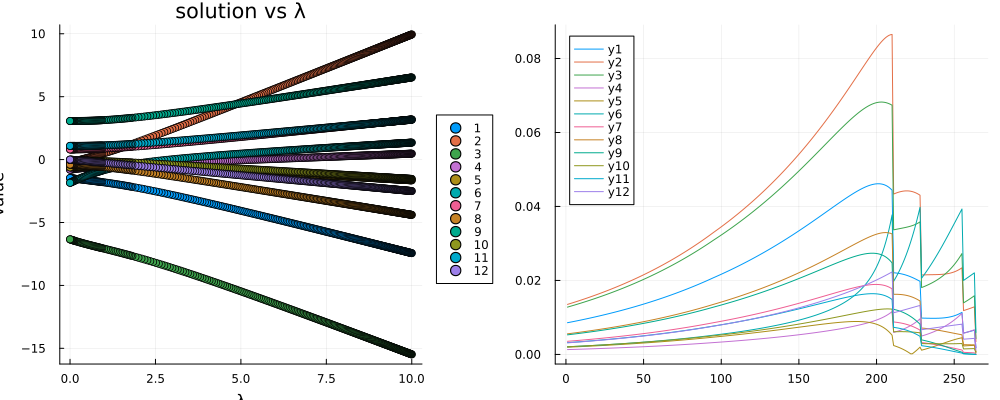

In [13]:
maximum_start_value = maximum(abs.(final_result.sol[1].x))
minimal_start_value = minimum(abs.(final_result.sol[1].x))
println("Maximum start value: ", maximum_start_value)
println("Minimal start value: ", minimal_start_value)
println("Ratio: ", maximum_start_value/minimal_start_value)
println("Newton tolerance: ", final_result.contparams.newton_options.tol)
println("Number of special points: ", length(final_result.specialpoint)-1)
println("Current tol = $tol")
println("Step: ", final_result.step[end])
println("Solution: ", extract_last_solution(final_result))
plot(
    plot_solution(final_result,find_all_sol_first_less),
    plot(solution_differences),
    size=(1000,400)
)